# Example 5.1 - Use catXAS to Perform a MRC-ALS Analysis on Normalzied XAS Spectra
## Authors: Anika Jalil (UCSB), Adam S. Hoffman (SLAC), Jason Chalmers (UCSB), Emmanuel (Noel) Hiennadi (Va Tech)
    Note: Code was streamlined using Claude Sonnet 4.5

In [1]:
# File/OS Handling:
import os

# Data Handling:
import pandas as pd
import numpy as np

# MCR-ASL handling:
from pymcr.constraints import ConstraintNonneg, ConstraintNorm

# CatXAS:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp
import pca
import mcrals

# Step 1. Load Spectra Data into a Pandas DataFrame

In [2]:
# Where is the Data Stored
XAS_dir_name = os.path.join(pwd, 'sample results')

# What is the name of the file (include extension)
fname = r'SnO2_TPR_NormXANES.csv'

# What is the separator?

sep = ',' # common options: '\t' ',' '\s'

# Energy Column?

e_col = 0

# Has Heder?

header = None # alternate option is to specify the row number of the header [default = 0]
header_lines = 1 # number of lines to skip for a long header

XAS_df = pd.read_csv(os.path.join(XAS_dir_name, fname), sep = sep, index_col = e_col, header = header, skiprows = header_lines)

# Step 2. Define Enery and Spectra Range to Perform MCR-ALS Analysis On

In [3]:
widgets_dict = pca.select_spectral_range(XAS_df, 
                     xlabel='Energy (eV)', 
                     ylabel='Absorption',
                     figsize=(10, 7))

interactive(children=(Dropdown(description='Energy Min:', options=(np.float64(29050.0), np.float64(29050.25), …

In [4]:
# Create a copy of the XAS data for MCR-ALS analysis:
df_mcrals = XAS_df.loc[widgets_dict['e_min'].value:widgets_dict['e_max'].value].iloc[:,widgets_dict['s_min'].value:widgets_dict['s_max'].value].copy()

# Step 3a. Determine Starting Spectra for MCR-ALS Analysis

Comparing seed selection methods for 3 components
Dataset: 1601 energy points × 49 spectra

PCA:
----------------------------------------
  ✓ Initialization time: 0.0207 s
  ✓ Selected columns: [np.int64(49), np.int64(32), np.int64(22)]
  ✓ Diversity score: 0.0024

K-Means:
----------------------------------------
  ✓ Initialization time: 1.9464 s
  ✓ Selected columns: [np.int64(17), np.int64(37), np.int64(30)]
  ✓ Diversity score: 0.0024

Dissimilarity:
----------------------------------------
  ✓ Initialization time: 0.0075 s
  ✓ Selected columns: [np.int64(5), np.int64(49), np.int64(31)]
  ✓ Diversity score: 0.0029

SIMPLISMA:
----------------------------------------
  ✓ Initialization time: 0.0071 s
  ✓ Selected columns: [np.int64(27), np.int64(8), np.int64(13)]
  ✓ Diversity score: 0.0002


SUMMARY:
----------------------------------------------------------------------
Method               Time(s)    Diversity   
--------------------------------------------------------------------

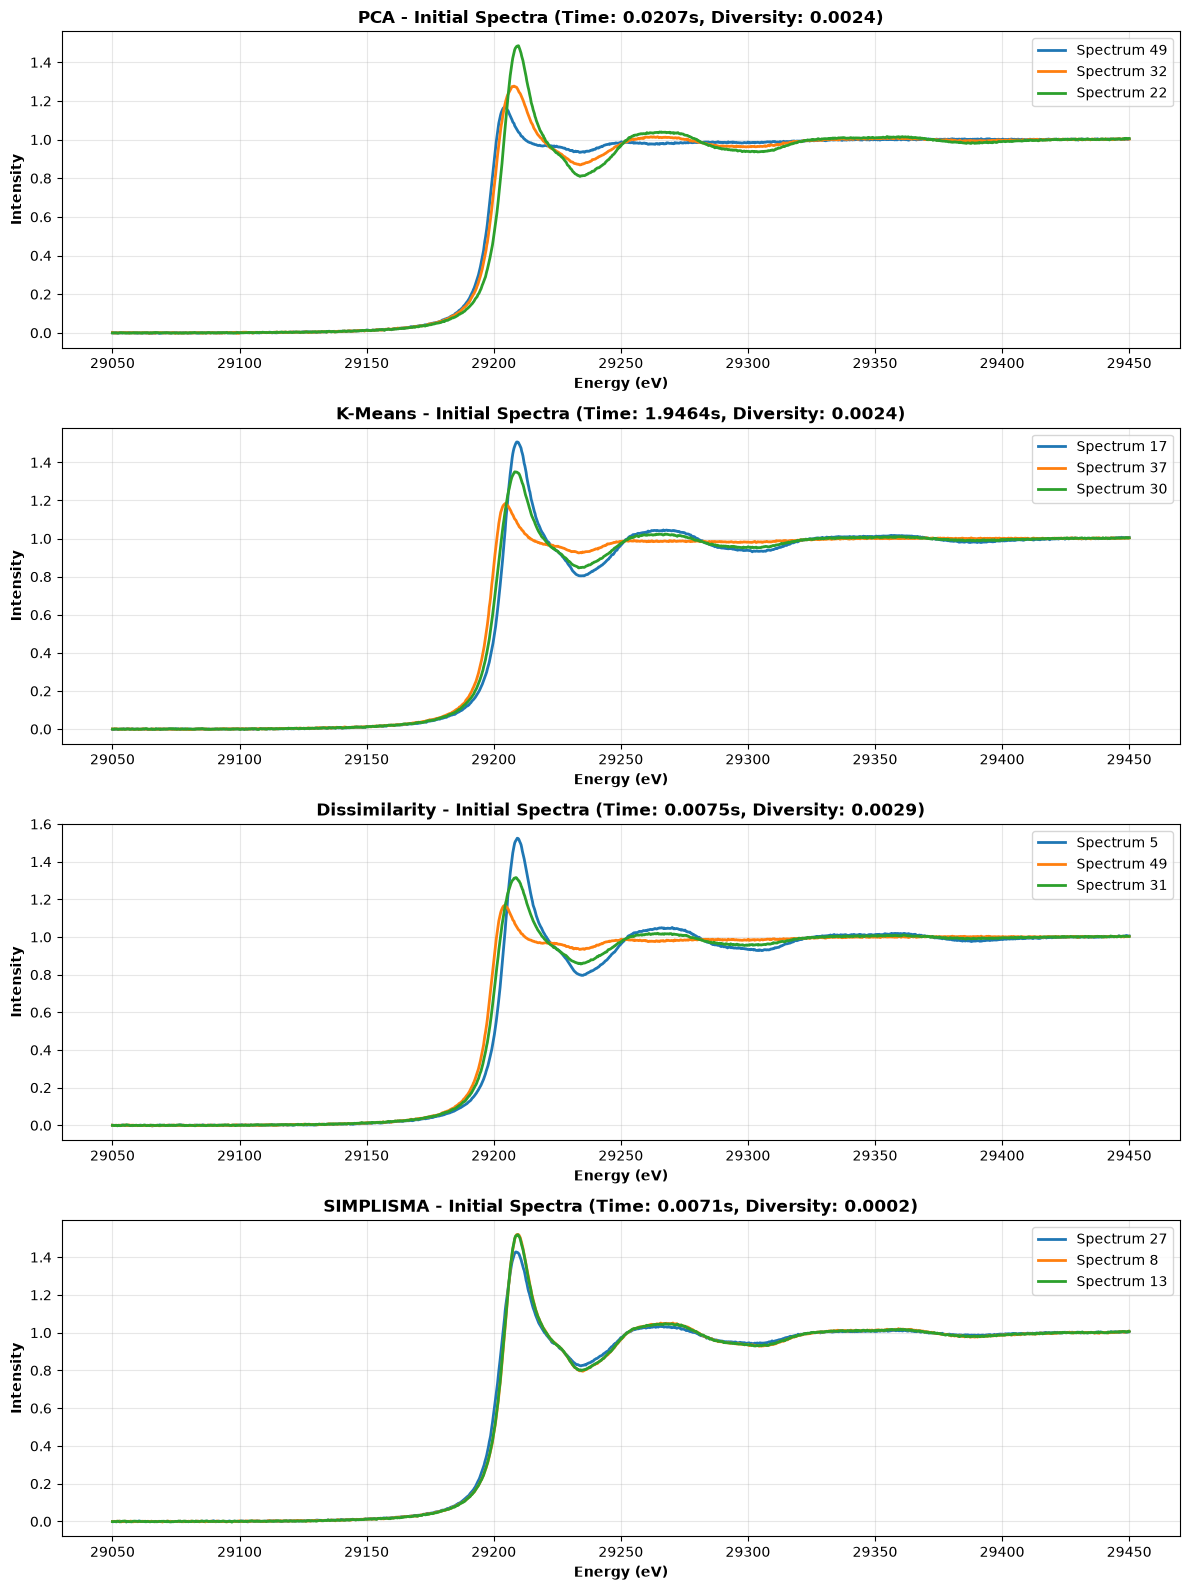

In [5]:
# Compare different functions for generating initial guesses

n_components = 3

indices_select_results, fig = mcrals.run_complete_comparison(df_mcrals, n_components)

In [37]:
# Choose the initial spectra guesses based upon the selection method

method = 'Dissimilarity' #['PCA', 'K-Means', 'Dissimilarity', 'SIMPLISMA']

#user chooses one line below
initial_spectra_indices = np.add(indices_select_results[method]['column_indices'],1)

# Step 3b. Set up the Constraints for the MCR-ALS Analysis

In [38]:
# Define zero constraints (custom constraint)
zero_dict = {
    #0: range(55, 57),  # Component 0 zero at indices 55-56
}
zero_constraint = mcrals.ConstraintZeroByIndex(zero_dict)

# Set up constraints
c_constraints = [ConstraintNonneg(), ConstraintNorm(), zero_constraint]
st_constraints = [ConstraintNonneg(), ConstraintNorm(axis = 0)]

# Step 3c. Run the MCR-ALS Analysis

In [39]:
# Run MCR-ALS
mcr_als_results = mcrals.run_mcr_als(
    df_data=df_mcrals,
    initial_spectra_indices=initial_spectra_indices,  # Which spectra to use as initial guess
    c_constraints=c_constraints,
    st_constraints=st_constraints,
    fast_solve=True,  # True = OLS (fast), False = NNLS (slow)
    max_iter=10000,
    tol_increase=10000,
    tol_n_increase=1e10,
    tol_err_change=1e-15,
    tol_n_above_min=1e10,
    perturb_initial=True,
    perturbation_amount=0.0001,
)

# Access results
C = mcr_als_results['C']    # Concentrations
ST = mcr_als_results['ST']  # Resolved spectra
R = mcr_als_results['R']    # Residuals

print(f"Converged: {mcr_als_results['converged']}")
print(f"Final error: {mcr_als_results['err']:.6e}")

MCR-ALS Analysis
Data shape: (49, 1601) (spectra × energy points)
Number of components: 3 (from 3 initial spectra)
Solver: OLS (fast)
Max iterations: 10000
Initial spectra indices (1-based): [ 5 49 31]
Initial spectra perturbed: ±0.01% at each energy point
Initial spectra shape: (3, 1601)
----------------------------------------------------------------------
Running MCR-ALS...
Error increased above fractional tol_increase (ST iter). Exiting


INFO [2026-07-03 16:00:04]: Error increased above fractional tol_increase (ST iter). Exiting


----------------------------------------------------------------------
Results:
  Iterations: 1/10000
  Converged: True
  Final error: 2.097092e-05
  Concentration matrix shape: (49, 3)
  Spectra matrix shape: (3, 1601)
  Residuals RMS: 4.579402e-03
Converged: True
Final error: 2.097092e-05


# Step 3d. Visualize S, C, and R from the MCR-ALS Analysis

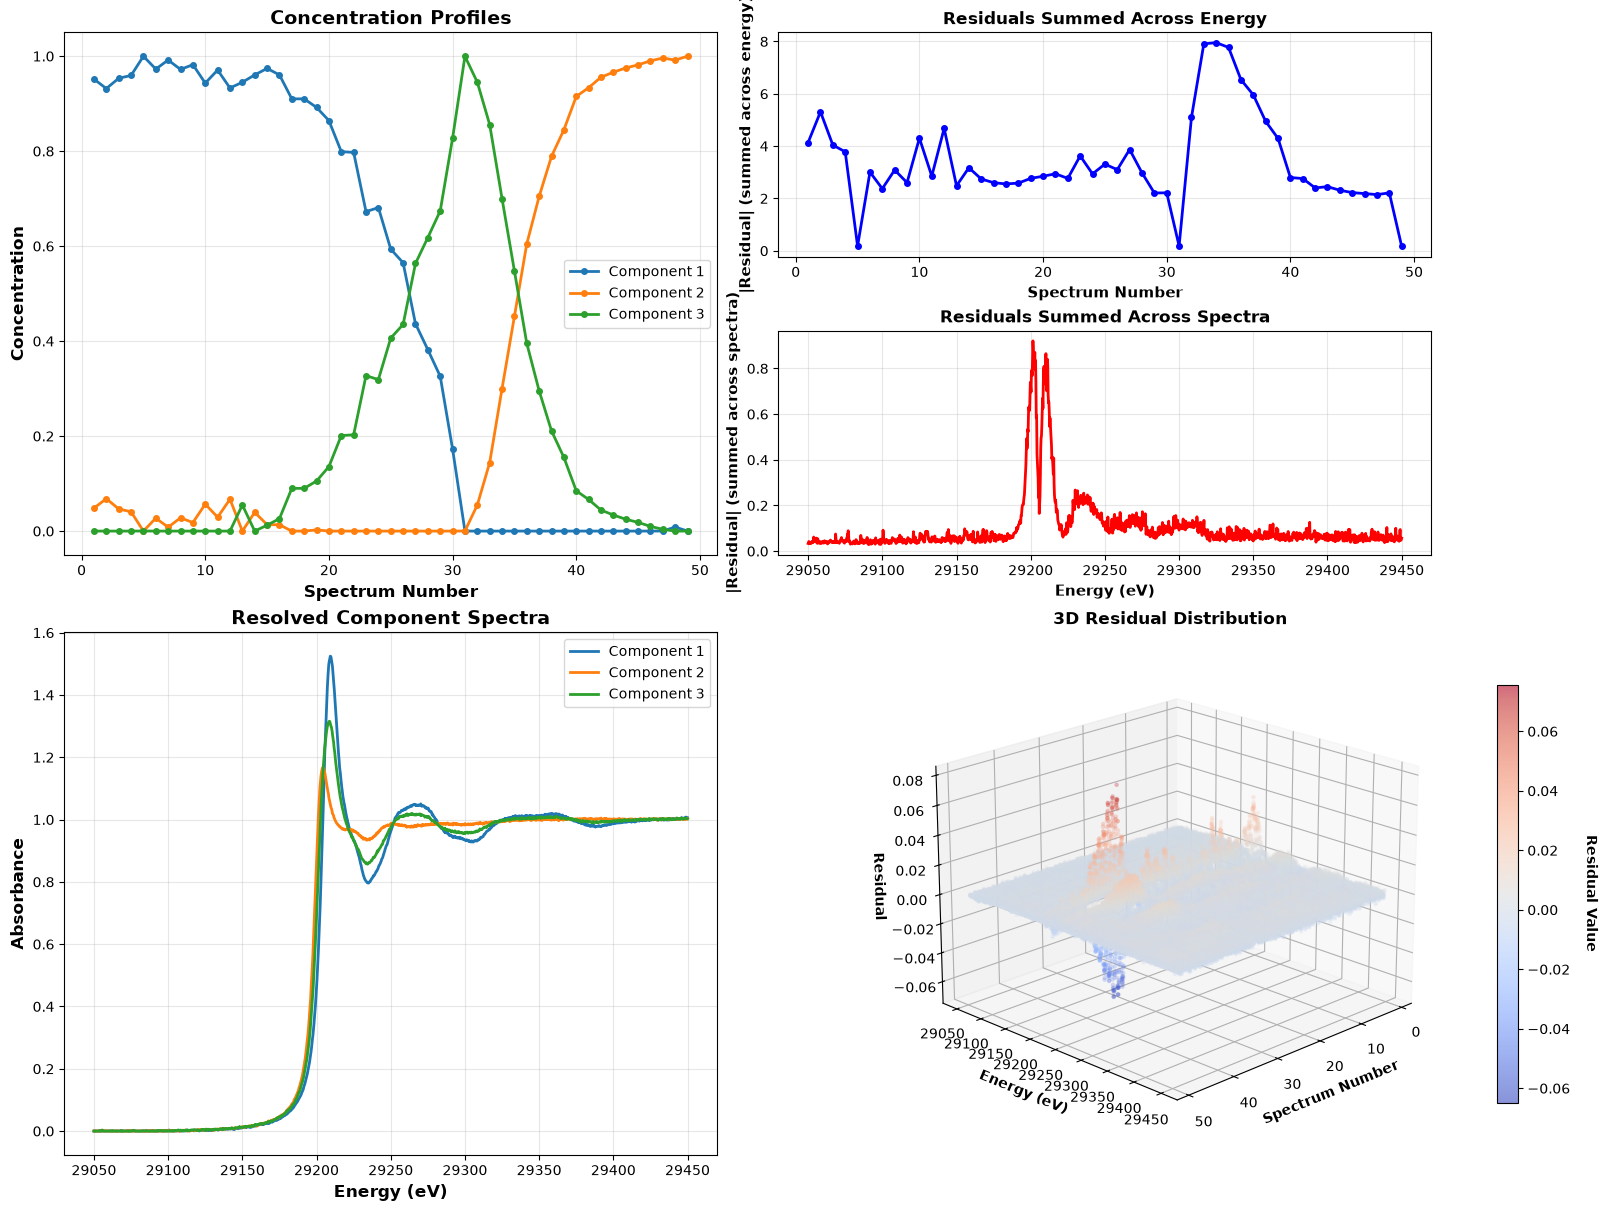

In [40]:
# Visualize results
fig = mcrals.visualize_mcr_results(mcr_als_results, df_mcrals)

# Step 3e. Reconstruct a Spectra from the MCR analysis

In [41]:
# Interactive version with dropdown and energy sliders
widget_dict = mcrals.plot_mcr_reconstruction_interactive(mcr_als_results, df_mcrals)

# Step 4d. Save MCR-ALS Results

In [42]:
# Save results
output_dir = os.path.join(pwd, 'sample results')

base_name = 'SnO2_TPR_MCR'

saved_files = mcrals.save_mcr_results(
    mcr_results=mcr_als_results,
    save_dir=output_dir,
    base_name=base_name
)

Saved concentrations to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_MCR_concentrations.csv
Saved spectra to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_MCR_spectra.csv
Saved residuals to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_MCR_residuals.csv
Saved summary to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results\SnO2_TPR_MCR_summary.txt

Summary:
  Number of components: 3
  Number of spectra: 49
  Energy range: 29050.00 - 29450.00 eV
  All files saved to: C:\Users\ashoff\OneDrive - SLAC National Accelerator Laboratory\Python Codes\GitHub\catxas\sample results
